# Assignment 8: Build a Natural Language to SQL RAG System

## Overview

Until now, we've exclusively worked with **unstructured textual data**, by loading documents, chunking them, embedding them into vector databases, and retrieving relevant context for question answering.

But here's an important reality: **most enterprise data isn't stored just as unstructured text.** Instead, it lives in **relational databases**, which organize data into structured tables with rows, columns, and relationships between entities. You may already be familiar with these systems as SQL databases, such as PostgreSQL, MySQL, SQLite, SQL Server, or Oracle. They are used by virtually every modern company to power core business data workflows behind the scenes.

In practice, that means the data you care about lives across many related tables: customers, accounts, orders/transactions, invoices, payments, product catalogs, inventory, support tickets, user activity, and more, which are connected through IDs and foreign keys. So if you want an AI system to be useful in the enterprise, it has to be good at unstructured text, **and** it has to reliably reason over structured data, generate correct queries, and return answers that are traceable back to the underlying tables.

In this assignment, we’re going to work with a sample relational (SQLite) database and build a system that can answer questions about it using natural language. The idea is that a user can ask questions like “Who are our top customers?” or “Which albums sold best last month?”, and the system will translate that into SQL, run it safely, and return the result in natural language. This is the core capability behind many conversational-based customer support agents and internal “data assistant” tools that can look up account details, orders, invoices, and activity on demand.

### The Challenge

Imagine you have a music store relational database with these tables, among many others:
- **Artists**: Information about musicians
- **Albums**: Music releases by artists
- **Tracks**: Individual songs on albums  
- **Customers**: People who buy music
- **Invoices**: Sales transactions

If you wanted to know "Who are our top 5 customers by total spending?", this question requires:
1. **Joining** the Customer and Invoice tables
2. **Aggregating** purchase amounts per customer
3. **Sorting** by total spending
4. **Limiting** to top 5 results

Think about how we embed unstructured data: We break text into chunks, embed each chunk, and retrieve the most similar passages at query time. Now picture a spreadsheet or database table with rows of values across columns and sheets, where meaning comes from the schema, including predefined business logic, column definitions, and relationships like keys and joins that tell you how those values should be interpreted. In other words, the “context” is not just in the text, it is in the structure too.

**You can't simply embed this structured data and do similarity search.** Why not? Because numbers like "145.50" or "3" in isolation lack context. Is that dollars, tracks, or an ID number? They only become meaningful when you know:
- Which table they're from
- Which columns they represent  
- How they relate to other tables

That is why, if we want an LLM to work with a database in the most natural way, we should let it speak the database’s native language.

### The Solution: Natural Language to SQL (NL2SQL)

Databases are built to be queried with SQL, so instead of embedding rows and hoping retrieval finds the answer, we have the LLM:

1. **Translate** users' natural language-based questions into SQL queries
2. **Execute** those queries against the database
3. **Format and present** the results back in natural language

### What Is SQL?

SQL (Structured Query Language) is the standard language for working with relational databases. It lets you select rows, filter and sort results, join multiple tables together, and aggregate data (such as sums, counts, and averages) to answer business questions accurately and repeatably.

In this project, we are using a sample database which models an imaginary digital music store with realistic relationships between artists, albums, tracks, customers, and invoices. The **Database Diagram** below shows the relationships between the tables in the sample database.

The database is rich enough to feel like a real business system. It includes media data based on a real iTunes library along with fictitious customer and employee profiles, and auto-generated sales transactions over a multi-year period. This gives you plenty of interesting questions to ask, like “What genres drive the most revenue?”, “Which customers spend the most?”, or “Which artists have the most tracks sold?”.

In this assignment, you'll:
- Understand **SQL basics** through practical examples
- Connect LLMs to relational databases
- Generate SQL from natural language questions
- Build a complete **NL2SQL RAG pipeline**
- Handle the unique challenges of structured data

Let's get started!

### Database Diagram

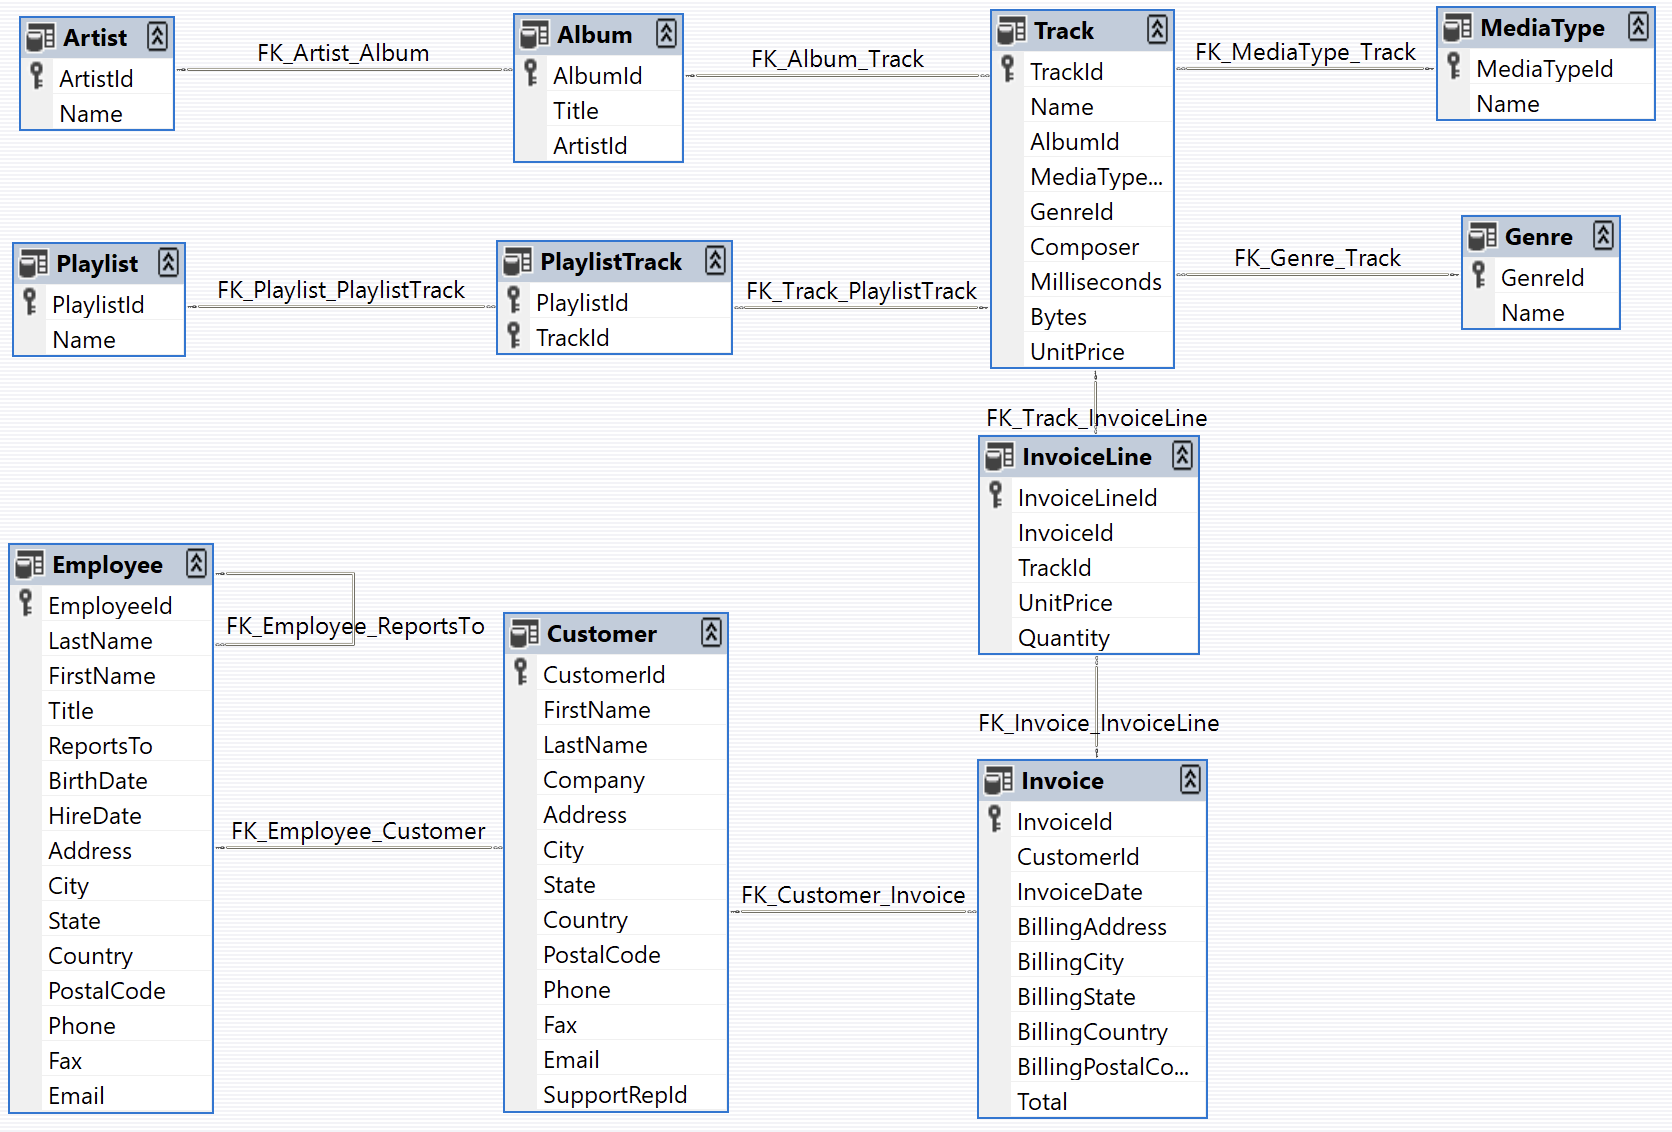

This diagram is a **schema** &mdash; also called an ERD &mdash; for the SQLite database we will be using. It is a map of the database: What “things” exist (tables), what attributes they have (columns), and how they connect (relationships).

### What Is a Table in SQL?
A **table** is like a spreadsheet with a fixed meaning:
- **Rows** represent individual records, such as one customer, one invoice, one track.
- **Columns** represent fields on that record, such as CustomerId, FirstName, and Total.
- Most tables have a **primary key**, which is often an `...Id` column, that uniquely identifies each row.

### How to Read This Diagram
- Each blue box is a **table** (Artist, Album, Track, Customer, Invoice, etc.).
- The list inside each box are the **columns** in that table.
- The key icon marks a **primary key** (unique identifier).
- Lines between tables represent **foreign key relationships**, meaning one table stores an ID that points to a row in another table. The `FK_...` labels show the constraint names.

### What This Schema Indicates
A few core relationships are easy to see and follow:
- **Artist → Album → Track**: an artist has many albums, and an album has many tracks.
- **Customer → Invoice → InvoiceLine**: a customer has many invoices, and each invoice has multiple line items (the individual tracks purchased).
- **Track → Genre/MediaType**: each track belongs to a genre and a media type.
- **Playlist ↔ Track** via **PlaylistTrack**: playlists and tracks have a many-to-many relationship, so there is a “link table” in between.

Once you see the schema, you can understand how SQL answers real questions. It selects the right tables, **joins tables along these relationships**, filters the right rows, and aggregates values like `Invoice.Total` or `InvoiceLine.Quantity` to compute results.

## Setup: Loading Libraries and Connecting to the Database

### Initial Setup

Let's import the packages we need for this assignment.

#### Run the Following Cell

In [1]:
# === Import Libraries ===
from langchain_community.utilities import SQLDatabase
from langchain_openai import ChatOpenAI
from langchain_classic.chains import create_sql_query_chain
from langchain_community.tools import QuerySQLDatabaseTool
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage
from operator import itemgetter
from IPython.display import display, Markdown
import pandas as pd
from sqlalchemy import create_engine

### Connecting to the Database

We'll use a sample SQLite database representing a digital music store. It contains 11 tables modeling a complete e-commerce system. In the code cell below, you will see that the path to the database is `db_uri = "sqlite:///data/Chinook.db"`. The code cell makes a connection to the database, and initializes an engine that actually runs SQL queries.

**What is SQLite?**
SQLite is a lightweight database system that stores all data in a single file. Unlike larger databases (PostgreSQL, MySQL) that run as separate servers, SQLite databases are just files on your computer, making them perfect for learning and prototyping.

**Connecting to the Database:**
Before we can query data, we need to establish a connection to our database. Think of this like opening a book before you can read it.

In the code below, we create two different connections to the same database:

1. `db = SQLDatabase.from_uri(db_uri)` &mdash; LangChain's database wrapper
- This is what LangChain uses to understand the database structure, i.e. tables, columns, relationships
- It lets LangChain automatically generate SQL by inspecting the schema
- We'll pass this to `create_sql_query_chain` later

2. `engine = create_engine(db_uri)` &mdash; SQLAlchemy's database engine
- This is the "executor" that actually runs SQL queries
- We'll use it with the `pandas` library to display query results as neatly formatted tables
- Think of it as the engine that powers our database operations

#### Run the Following Cell

In [2]:
# === Connect to Database ===
db_uri = "sqlite:///data/Chinook.db"
db = SQLDatabase.from_uri(db_uri)

# Create SQLAlchemy engine for direct queries
engine = create_engine(db_uri)

# Display available tables
tables = db.get_usable_table_names()

output = f"""
## Database Connected

**Database:** Digital Music Store  
**Type:** {db.dialect}                             
**Tables ({len(tables)}):** {', '.join(tables)}

The database models a complete music store ecosystem with artists, albums, tracks, customers, employees, and sales data.
"""

display(Markdown(output))


## Database Connected

**Database:** Digital Music Store  
**Type:** sqlite                             
**Tables (11):** Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, Track

The database models a complete music store ecosystem with artists, albums, tracks, customers, employees, and sales data.


## Introduction to SQL

Before we build our NL2SQL system, let's understand SQL basics using our database. Remember that **SQL** is how we ask questions to relational databases.

### The Four Core SQL Operations

1. **SELECT**: Choose which columns to retrieve
2. **FROM**: Specify which table to query (i.e., retrieve from)
3. **WHERE**: Filter rows based on conditions (e.g,. only rows where a value is above a certain threshold)
4. **ORDER BY/LIMIT**: Sort and limit results (how to present the retrieved data)

Let's see these in action!

### Example 1: Simple SELECT &mdash; Viewing Artists

The simplest SQL query: Get a sample of the data from a table.

#### Run the Following Cell

In [3]:
# === SQL Example 1: SELECT all artists ===
query = """SELECT * 
FROM Artist 
LIMIT 10;"""
df = pd.read_sql_query(query, engine)

output = f"""
## SQL Query: View Artists

**Query:**
```sql
{query}
```

**Results:**
"""

display(Markdown(output))
display(df)


## SQL Query: View Artists

**Query:**
```sql
SELECT * 
FROM Artist 
LIMIT 10;
```

**Results:**


,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains
5,6,Antônio Carlos Jobim
6,7,Apocalyptica
7,8,Audioslave
8,9,BackBeat
9,10,Billy Cobham


**What this does:**
- `SELECT *` = Get all columns
- `FROM Artist` = From the `Artist` table  
- `LIMIT 10` = Show only first 10 rows

**Note:** `SELECT *` gets ALL columns. If you need to select only the columns you need, it's just a matter of replacing the '*' with the name of the columns, e.g., `SELECT Name, ArtistId`.

### Example 2: SELECT Specific Columns

Instead of `*`, specify exact columns you want. Let's try this with the `Track` table. 

#### Run the Following Cell

In [4]:
# === SQL Example 2: SELECT specific columns ===
query = """SELECT TrackId, Name, Composer, Milliseconds 
FROM Track 
LIMIT 10;
"""

df = pd.read_sql_query(query, engine)

output = f"""
## SQL Query: View Track Details

**Query:**
```sql
{query}
```

**Results:**
"""

display(Markdown(output))
display(df)


## SQL Query: View Track Details

**Query:**
```sql
SELECT TrackId, Name, Composer, Milliseconds 
FROM Track 
LIMIT 10;

```

**Results:**


,TrackId,Name,Composer,Milliseconds
0,1,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson",343719
1,2,Balls to the Wall,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562
2,3,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619
3,4,Restless and Wild,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051
4,5,Princess of the Dawn,Deaffy & R.A. Smith-Diesel,375418
5,6,Put The Finger On You,"Angus Young, Malcolm Young, Brian Johnson",205662
6,7,Let's Get It Up,"Angus Young, Malcolm Young, Brian Johnson",233926
7,8,Inject The Venom,"Angus Young, Malcolm Young, Brian Johnson",210834
8,9,Snowballed,"Angus Young, Malcolm Young, Brian Johnson",203102
9,10,Evil Walks,"Angus Young, Malcolm Young, Brian Johnson",263497


**What this does:**
- `SELECT TrackId, Name, Composer, Milliseconds` = Get only these 4 columns
- `FROM Track` = From the `Track` table
- `LIMIT 10` = Show first 10 tracks

Selecting specific columns can be more efficient than `SELECT *`, especially for large tables.

### Example 3: Filtering With WHERE

Use `WHERE` to filter rows based on conditions. Let's try this with the `Customer` table, and look for only US-based customers. 

#### Run the Following Cell

In [5]:
# === SQL Example 3: Filtering with WHERE ===
query = """SELECT FirstName, LastName, Country, Email
FROM Customer
WHERE Country = 'USA'
LIMIT 10;"""

df = pd.read_sql_query(query, engine)

output = f"""
## SQL Query: Find U.S. Customers

**Query:**
```sql
{query}
```

**Results:**
"""

display(Markdown(output))
display(df)


## SQL Query: Find U.S. Customers

**Query:**
```sql
SELECT FirstName, LastName, Country, Email
FROM Customer
WHERE Country = 'USA'
LIMIT 10;
```

**Results:**


,FirstName,LastName,Country,Email
0,Frank,Harris,USA,fharris@fakeemail.test
1,Jack,Smith,USA,jacksmith@example.org
2,Michelle,Brooks,USA,michelleb@student.example
3,Tim,Goyer,USA,tgoyer@example.org
4,Dan,Miller,USA,dmiller@placeholder.example
5,Kathy,Chase,USA,kachase@example.org
6,Heather,Leacock,USA,hleacock@example.com
7,John,Gordon,USA,johngordon22@placeholder.example
8,Frank,Ralston,USA,fralston@example.com
9,Victor,Stevens,USA,vstevens@placeholder.example


**What this does:**
- `SELECT FirstName, LastName, Country, Email` = Get customer details
- `FROM Customer` = From `Customer` table
- `WHERE Country = 'USA'` = Only customers in USA
- `LIMIT 10` = Show first 10 matches

`WHERE` acts like a filter—only rows matching the condition are returned.

### Example 4: JOIN &mdash; Combining Related Tables

Real questions often require data from multiple tables. To do so, we use `JOIN` to connect them. Let's try this with the `Artist` and `Album` tables, and retrieve the list of albums released by each artist.

#### Run the Following Cell

In [6]:
# === SQL Example 4: JOIN tables ===
query = """SELECT Artist.Name AS ArtistName, Album.Title AS AlbumTitle
FROM Artist
JOIN Album ON Artist.ArtistId = Album.ArtistId
LIMIT 10;"""

df = pd.read_sql_query(query, engine)

output = f"""
## SQL Query: Artists with Their Albums

**Query:**
```sql
{query}
```

**Results:**
"""

display(Markdown(output))
display(df)


## SQL Query: Artists with Their Albums

**Query:**
```sql
SELECT Artist.Name AS ArtistName, Album.Title AS AlbumTitle
FROM Artist
JOIN Album ON Artist.ArtistId = Album.ArtistId
LIMIT 10;
```

**Results:**


,ArtistName,AlbumTitle
0,AC/DC,For Those About To Rock We Salute You
1,Accept,Balls to the Wall
2,Accept,Restless and Wild
3,AC/DC,Let There Be Rock
4,Aerosmith,Big Ones
5,Alanis Morissette,Jagged Little Pill
6,Alice In Chains,Facelift
7,Antônio Carlos Jobim,Warner 25 Anos
8,Apocalyptica,Plays Metallica By Four Cellos
9,Audioslave,Audioslave


**What this does:**
- `SELECT Artist.Name AS ArtistName, Album.Title AS AlbumTitle` = Get artist name and album title, and assign column name aliases using the 'AS' clause
- `FROM Artist` = Start retrieval from `Artist` table
- `JOIN Album ON Artist.ArtistId = Album.ArtistId` = Connect the `Artist` table to `Album` table where IDs match
- `AS` = Rename columns for clarity in results (notice the column titles in the output display above)

`JOIN` connects tables using a common column (here, `ArtistId`). This lets us answer questions that require data from multiple tables.

You will also note here that Artist → has many → Albums

### Example 5: Aggregation &mdash; Counting and Summing

Use aggregate functions like `COUNT()`, `SUM()`, `AVG()` to summarize data. Let's try to find out who the top 5 customers are on the basis of spending. Conceptually, this would require aggregating the total spend data for each customer, and displaying the sorted results.

#### Run the Following Cell

In [7]:
# === SQL Example 5: Aggregation ===
query = """SELECT Customer.FirstName, Customer.LastName, SUM(Invoice.Total) AS TotalSpent
FROM Customer
JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
GROUP BY Customer.CustomerId
ORDER BY TotalSpent DESC
LIMIT 5;"""

df = pd.read_sql_query(query, engine)

output = f"""
## SQL Query: Top 5 Customers by Spending

**Query:**
```sql
{query}
```

**Results:**
"""

display(Markdown(output))
display(df)


## SQL Query: Top 5 Customers by Spending

**Query:**
```sql
SELECT Customer.FirstName, Customer.LastName, SUM(Invoice.Total) AS TotalSpent
FROM Customer
JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId
GROUP BY Customer.CustomerId
ORDER BY TotalSpent DESC
LIMIT 5;
```

**Results:**


,FirstName,LastName,TotalSpent
0,Helena,Holý,49.62
1,Richard,Cunningham,47.62
2,Luis,Rojas,46.62
3,Ladislav,Kovács,45.62
4,Hugh,O'Reilly,45.62


**What this does:**
- `SELECT Customer.FirstName, Customer.LastName` = Get customer names
- `SUM(Invoice.Total) AS TotalSpent` = Add up all invoice totals per customer
- `FROM Customer JOIN Invoice` = Connect customer and invoice tables
- `GROUP BY Customer.CustomerId` = Calculate sum for each customer
- `ORDER BY TotalSpent DESC` = Sort highest to lowest (DESC standing for descending order)
- `LIMIT 5` = Show only top 5

**Key concepts:**
- `SUM()` adds up values
- `GROUP BY` groups rows for aggregation  
- `ORDER BY DESC` sorts high to low
- This answers business questions like "Who are our best customers?"

**You now understand the SQL basics needed for this project!**

## From SQL to Natural Language: Building the NL2SQL Pipeline

Now that you understand SQL, here's the challenge: **most users don't speak SQL.** They want to ask questions in natural language/plain English, lile:
- "Who are the top 5 customers by spending?"
- "How many employees do we have?"
- "What are the three biggest hits?"

**Our solution:** Use the LLM as a "translator" between the user and the database. The user asks a question in plain English, and the LLM converts it into SQL, the database’s native query language. The database then does what it’s built to do: Run that query over the real tables and return exact results. Finally, the LLM takes the generated SQL code, the returned results, and the user's original question to generate the final answer in natural language.

This approach has a few big advantages:

- **Precision**: The database computes the answer directly from the source-of-truth tables, not from approximate keyword or similarity matches.
- **Transparency**: You can inspect the generated SQL to see exactly how the answer was derived.
- **Scalability**: The same pattern works whether you have thousands of rows or billions, because the database typically handles optimization.

### The NL2SQL Pipeline

```
User Question (Natural Language)
        ↓
  [LLM generates SQL (+ text)]
        ↓
  [LLM cleans above to return only SQL]
        ↓
    SQL Query
        ↓
   [Execute on database]
        ↓
   Raw Results
        ↓
  [LLM generates answer]
        ↓
Natural Language Answer
```

Let's build this step by step!

## Step 1: Initialize the LLM

#### Run the Following Cell

In [8]:
# === Initialize ChatOpenAI ===
llm = ChatOpenAI(model="gpt-4o")

This code initializes our LLM using LangChain's `ChatOpenAI` wrapper. We're using gpt-4o, which will handle both SQL generation and answer formatting.

## Step 2: Generate SQL From Natural Language

Now comes the magic: Converting a natural language question into a SQL query automatically. LangChain provides the `create_sql_query_chain` function, which constructs a chain that generates SQL queries from natural-language questions.

This LangChain function creates a specialized chain that:
1. Takes a natural language question as input
2. Inspects the database structure (tables, columns, relationships)
3. Generates appropriate SQL to answer the question

Why we pass two arguments:

`write_query = create_sql_query_chain(llm, db)`

- `llm`: The language model (gpt-4o) that will generate the SQL
- `db`: The database connection that we had established before, and gives the LLM access to:
    - Table names (`Artist`, `Album`, `Track`, `Customer`, etc.)
    - Column names within each table
    - Data types (text, numbers, dates)
    - Relationships between tables

The LLM uses this schema information to write syntactically correct SQL for your specific database.

**How it works**:

When you call `write_query.invoke({"question": "...})`, the chain:
1. Retrieves the database schema
2. Constructs a prompt telling the LLM it's a "SQLite expert"
3. Includes the schema and your question
4. Asks the LLM to generate SQL
5. Returns the LLM's response

**What to expect**:

The response typically includes more than just SQL. It can contain explanations, reasoning, and formatting. That's why we'll need a cleaning step later.

Let's see it in action.

#### Run the Following Cell

In [9]:
# === Generate SQL from natural language ===
write_query = create_sql_query_chain(llm, db)

# Test with a question
question = "Who are the top 5 customers on the basis of spending?"
response = write_query.invoke({"question": question})

output = f"""
## SQL Generation Demo

**Question:** "{question}"

**Generated Response:**

{response}

"""

print(response)

```sql
SELECT "C"."FirstName", "C"."LastName", SUM("I"."Total") AS "TotalSpending"
FROM "Customer" AS "C"
JOIN "Invoice" AS "I" ON "C"."CustomerId" = "I"."CustomerId"
GROUP BY "C"."CustomerId"
ORDER BY "TotalSpending" DESC
LIMIT 5;
```


**Observe Output:** The LLM generates SQL code, but it's wrapped in either explanatory text and/or formatting (such as <code>```sql</code> at the top of the generated answer). To run the query correctly, we need to extract just the SQL query, and nothing else.

### Understanding What the LLM Sees

Before, proceeding, let's see the actual prompt sent to the LLM in the code cell above. This shows the instructions and context it uses to generate SQL.

#### Run the Following Cell

In [10]:
# === Display the prompt template ===
write_query.get_prompts()[0].pretty_print()

You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, then look at the results of the query and return the answer to the input question.
Unless the user specifies in the question a specific number of examples to obtain, query for at most 5 results using the LIMIT clause as per SQLite. You can order the results to return the most informative data in the database.
Never query for all columns from a table. You must query only the columns that are needed to answer the question. Wrap each column name in double quotes (") to denote them as delimited identifiers.
Pay attention to use only the column names you can see in the tables below. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.
Pay attention to use date('now') function to get the current date, if the question involves "today".

Use the following format:

Question: Question here
SQLQuery: SQL Query to run
SQLResult: Result

**Observe the output:** The prompt includes:
- Instructions to be a SQLite expert
- Best practices (`LIMIT`, specific columns)
- Table schema information
- Format structure

This guides the LLM to generate high-quality SQL.

**Notice the following in this prompt**:

The prompt LangChain automatically constructs is quite sophisticated. Let's break down each component:

1. **Role definition:**
- "You are a SQLite expert." This helps set the LLM's context and expertise level, and primes the model to think like a database professional

2. **Best practices built-in:**
- `LIMIT` clause enforcement: "query for at most 5 results using the `LIMIT` clause." This prevents accidentally retrieving millions of rows, and makes queries faster and results more manageable.
- Column selectivity: "Never query for all columns from a table," which forces specific column selection (e.g., `SELECT Name, Price` not `SELECT *`) preventing any data extraction bottlenecks from occuring 
- Column name validation: "only use the column names you can see in the tables below", which prevents hallucinating non-existent columns, and reduces SQL errors
- Ordering for relevance: "You can order the results to return the most informative data", which encourages using `ORDER BY` for meaningful results. Example: `ORDER BY sales DESC` when looking for "top customers"

3. **Database schema context:**
- `{table_info}` &mdash; This placeholder gets replaced with your actual database structure
- Table names: Artist, Album, Track, Customer, Invoice, etc.
- Column names and types for each table
- This is why the LLM knows what columns exist and what they're called

4. **Structured output format:**
```
Question: Question here
SQLQuery: SQL Query to run
SQLResult: Result of the SQLQuery
Answer: Final answer here
```
- This block of the prompt guides the LLM to structure its response consistently
- Makes it easier to extract the SQL later (though we'll still need cleaning)

5. **Your question:**
- `{input}` &mdash; This placeholder gets replaced with your actual question during runtime
- Example: "Who are the top 5 customers by spending?"

Why all of this matters:

This prompt engineering is doing heavy lifting behind the scenes. Without these instructions, the LLM might:
- Generate SQL for the wrong database type (PostgreSQL syntax instead of SQLite)
- Create inefficient queries (`SELECT *` from million-row tables)
- Hallucinate table or column names that don't exist
- Return unstructured responses that are hard to parse

LangChain has encoded many best practices into this template, saving you from engineering it yourself. It’s a solid starting point that can easily extend for your organization’s specific database, schema conventions, security requirements, and guardrails.

## Cleaning the SQL Query

As you saw, the LLM returns SQL wrapped in some text and/or formatting. We need a function to extract **only the SQL query** so we can execute it.

### The Problem

When we ask the LLM to generate SQL, it often returns more than just the query. This happens because:

1. **The LLM is trained to be helpful**: It wants to explain what it's doing
2. **Markdown formatting**: The LLM often wraps code in markdown blocks like ` ```sql ... ``` `

**LLM returns:**

    Here's the SQL query:
    ```sql
    SELECT Track.Name, COUNT(PlaylistTrack.TrackId) AS AppearanceCount
    FROM Track
    JOIN PlaylistTrack ON Track.TrackId = PlaylistTrack.TrackId
        GROUP BY Track.Name
    ORDER BY AppearanceCount DESC
    LIMIT 3;
    ```
This query joins the Track and PlaylistTrack tables to count how many playlists each track appears in, then orders by that count and limits to the top 3.


**We need:**
```sql
SELECT Track.Name, COUNT(PlaylistTrack.TrackId) AS AppearanceCount
FROM Track
JOIN PlaylistTrack ON Track.TrackId = PlaylistTrack.TrackId
GROUP BY Track.Name
ORDER BY AppearanceCount DESC
LIMIT 3;
```

**Why is this a problem?**
- The database engine expects **pure SQL**, not markdown or explanations. Extra text will cause syntax errors when we try to execute. We need to extract just the executable SQL string.

### The Solution: Using an LLM to Clean LLM Output

Here's an interesting approach: We'll use an LLM to clean the output!

**Why does this work?**
- LLMs are excellent at text extraction and transformation tasks
- It's easier to write a prompt that says "extract just the SQL" than to write regex patterns for every possible formatting variation
- The LLM understands both SQL syntax and markdown formatting
- This approach is robust to different response formats

**The cleaning function structure:**

```python
def clean_sql_query(response):
    """Extract only the SQL query from LLM response"""
    prompt = f"""
    [Your cleaning instructions here]
    Here is a string that contains a SQL query: {response}"""

    clean_response = llm.invoke([HumanMessage(content=prompt)])
    return clean_response.content
```

**How it works:**
1. **Input**: The messy LLM response with SQL + text + formatting
2. **Cleaning prompt**: Instructions telling the LLM to extract only the SQL
3. **LLM invocation**: Send the cleaning prompt to the LLM
4. **Output**: Clean, executable SQL

**What makes a good cleaning prompt?**

A good cleaning prompt should:
- Be specific about what to extract ("only the SQL query")
- Be explicit about what to remove ("no markdown blocks", "no explanations")
- Emphasize the output format ("directly executable SQL")
- Work for any SQL query (not hard-coded to specific examples)

**Alternative approaches &mdash; and why we don't use them:**

1. **Regex patterns**: Too brittle as LLM response formats vary
2. **String splitting**: Fails when explanations contain SQL-like keywords
3. **Parsing markdown**: Works for ` ```sql ``` ` blocks but not plain text responses

Using an LLM for cleaning is more flexible and handles edge cases better.

### The Solution in Action

The function below uses another LLM call to extract just the SQL. Inspect the code to see how it works:

#### Run the Following Cell

In [11]:
# === Example: SQL Cleaning Function ===
def clean_sql_query_example(response):
    """Extract just the SQL query from LLM response"""
    prompt = f"""Here is a string that contains a SQL query: {response}

Extract only the SQL query from this string and return it with no additional text.
Do not include markdown code blocks like ```sql
Do not include any explanations.
Return only the executable SQL query."""
    
    clean_response = llm.invoke([HumanMessage(content=prompt)])
    return clean_response.content

# Test it
test_response = write_query.invoke({"question": "How many employees are there?"})
cleaned = clean_sql_query_example(test_response)

output = f"""
## SQL Cleaning Example

**Original LLM Response:**

{test_response}


**Cleaned SQL:**


{cleaned}

"""
print(output)


## SQL Cleaning Example

**Original LLM Response:**

```sql
SELECT COUNT("EmployeeId") AS "NumberOfEmployees" FROM "Employee";
```


**Cleaned SQL:**


SELECT COUNT("EmployeeId") AS "NumberOfEmployees" FROM "Employee";




**Result:** Now we have executable SQL with no extra formatting!

## Graded Cell: Write the SQL Cleaning Prompt

Now it's your turn! Complete the `clean_sql_query` function by writing a prompt that extracts only the SQL query from an LLM response. The parameter `response` contains the raw output produced by an LLM and is passed into the function as an argument. 

Your task is to write instructional text that tells the LLM how to extract the clean SQL code from `response`.

**Requirements:**

Create a variable named `prompt`, and assign it a prompt that instructs the LLM to:
- Extract only the SQL query from  `response`
- Emphasize NO markdown code blocks (like <code>```sql</code>)
- Emphasize NO explanations or additional text  
- The output should be directly executable SQL

**Hints:**
- Start by explaining what the variable `response` contains. **Note**: use the notation `{response}` in your prompt to access the variable's contents.
- Be very specific about what NOT to include
- State clearly that you want ONLY the SQL query
- The prompt should work for any SQL query
- Make sure to enclose the entire prompt in triple quotation marks (`"""`) so it is treated as a single string.

## Graded Cell

The cell below will be graded. Replace the line `raise NotImplementedError("Your code is missing.")` with your code. Enter your solution and then run the following cell.

In [12]:
# === Graded: SQL Cleaning Function ===

def clean_sql_query(response):
    """Extract only the SQL query from LLM response"""
    # YOUR CODE HERE
    prompt = f"""Here is a string that contains a SQL query: {response}

Extract only the SQL query from this string and return it with no additional text.
Do not include markdown code blocks like ```sql
Do not include any explanations.
Return only the executable SQL query."""
    # END OF YOUR CODE
    
    clean_response = llm.invoke([HumanMessage(content=prompt)])
    return clean_response.content

# Test your function
test_response = write_query.invoke({"question": "What are the top 3 albums by sales?"})
cleaned = clean_sql_query(test_response)

output = f"""
## Your SQL Cleaning Test

**Original Response:**

{test_response}

**Your Cleaned SQL:**

{cleaned}

"""

print(output)


## Your SQL Cleaning Test

**Original Response:**

To determine the top 3 albums by sales, we first need to aggregate sales per album. This can be done by summing the totals from the `Invoice` table for tracks belonging to each album in the `Track` table.

Here's the query to find the top 3 albums by sales:

```sql
SQLQuery: 
SELECT "Album"."Title", SUM("InvoiceLine"."UnitPrice" * "InvoiceLine"."Quantity") as TotalSales
FROM "Album"
JOIN "Track" ON "Album"."AlbumId" = "Track"."AlbumId"
JOIN "InvoiceLine" ON "Track"."TrackId" = "InvoiceLine"."TrackId"
GROUP BY "Album"."Title"
ORDER BY TotalSales DESC
LIMIT 3
```

However, I cannot execute the query and provide the answer as I don't have direct access to your database. Normally, after running the above query, the resulting list of album titles, along with their total sales, would provide the answer.

**Your Cleaned SQL:**

SELECT "Album"."Title", SUM("InvoiceLine"."UnitPrice" * "InvoiceLine"."Quantity") as TotalSales
FROM "Album"
JOIN "

When done correctly, you'll see clean, executable SQL with no markdown formatting or explanatory text. The query should be ready to pass directly to the database.

## Step 3: Executing SQL Queries

Now that we can generate and clean SQL, we need to execute it against the database. This is where the actual data retrieval happens.

### Understanding `QuerySQLDataBaseTool`

LangChain provides `QuerySQLDataBaseTool` as a safe wrapper around database execution. Think of it as a specialized function that:
- Takes a SQL query string as input
- Executes it against the database connection (`db`) we created earlier
- Returns the raw results as a string
- Handles errors gracefully (e.g., syntax errors in SQL)

**Why use a tool instead of running SQL directly?**
- **Safety**: It prevents certain dangerous operations if configured (though our setup allows read-only `SELECT` queries)
- **Consistency**: Returns results in a standard format that works well with LangChain chains
- **Error handling**: Catches and formats database errors in a chain-friendly way

**What the results look like:**
The tool returns results as Python tuple strings: `"[(8,)]"` for a single value, or `"[('Helena', 'Smith', 51.62), ('Richard', 'Cunningham', 17.49)]"` for multiple rows.

This raw answer format is what we pass to our answer generation step later. 

Let's try this now, by attempting to print the number of employees by using the `COUNT(*)` command. 

#### Run the Following Cell

In [13]:
# === Execute a SQL query ===
execute_query = QuerySQLDatabaseTool(db=db)

# Test with a clean SQL query
test_sql = "SELECT COUNT(*) FROM Employee;"
result = execute_query.invoke(test_sql)

output = f"""
## Query Execution Demo

**SQL Query:**
```sql
{test_sql}
```

**Database Result:**
```
{result}
```

"""

display(Markdown(output))


## Query Execution Demo

**SQL Query:**
```sql
SELECT COUNT(*) FROM Employee;
```

**Database Result:**
```
[(8,)]
```



**What happened:** The query was executed as expected, and the raw results were returned. We now have the data for answer generation.

## Chaining the Components

Now let's chain our three components together:
1. **Generate SQL** (`write_query`)
2. **Clean SQL** (`clean_sql_query`)  
3. **Execute SQL** (`execute_query`)

You have already seen that the pipe operator (`|`) is LangChain's way of connecting components in a sequence. It's inspired by Unix pipes, where data flows from left to right:

```python
result = component1 | component2 | component3
```

**How it works:**
1. Input goes to `component1`
2. Output of `component1` becomes input to `component2`
3. Output of `component2` becomes input to `component3`
4. Final output is returned

**In our NL2SQL case, this is how it flows:**

```
{"question": "How many employees?"}
         ↓
    write_query
         ↓
"SQLQuery: SELECT COUNT(*) FROM Employee; This query..."
         ↓
  clean_sql_query
         ↓
"SELECT COUNT(*) FROM Employee;"
         ↓
  execute_query
         ↓
     "[(8,)]"
```

**Key insight:** Each component expects specific input and produces specific output. The pipe operator automatically passes output from one component to the next, creating a seamless data pipeline.

**Why this matters:**
- **Composable**: You can easily add, remove, or reorder components
- **Readable**: The flow of data is clear and linear
- **Reusable**: Each component can be used in different chains

Here's a working example:

#### Run the Following Cell

In [14]:
# === Example: Complete Query Chain ===
example_chain = write_query | clean_sql_query | execute_query

# Test it
question = "How many employees are there?"
result = example_chain.invoke({"question": question})

output = f"""
## Complete Query Chain Example

**Question:** "{question}"

**Result:** `{result}`
"""

display(Markdown(output))


## Complete Query Chain Example

**Question:** "How many employees are there?"

**Result:** `[(8,)]`


**What happened:**
1. `write_query` generated SQL code with extra text and formatting
2. `clean_sql_query` extracted just the SQL from the above
3. `execute_query` ran the clean SQL query from above on the database to return the result

The chain worked end-to-end as expected.

## Graded Cell: Assemble the Query Chain

Your task: Create a chain that pipes the three components in the correct order.

**Requirements:**

1. Create a variable named `chain`
2. Assign the variable a chain of the three components in the following order:
    - Start with `write_query`
    - Pipe to `clean_sql_query`
    - Pipe to `execute_query`
3. Use the pipe operator (`|`)

**Hint:** Think about the data flow: Question → SQL with formatting and text → clean SQL → results

## Graded Cell

The cell below will be graded. Replace the line `raise NotImplementedError("Your code is missing.")` with your code. Enter your solution and then run the following cell.

In [15]:
# === Graded: Query Chain Assembly ===

# YOUR CODE HERE
chain = write_query | clean_sql_query | execute_query
# END OF YOUR CODE

### Test your chain
test_question = "What are the top 3 albums by sales?"

result = chain.invoke({"question": test_question})
output = f"""
## Your Query Chain Test

**Question:** "{test_question}"

**Result:**
```
{result}
```

"""
display(Markdown(output))


## Your Query Chain Test

**Question:** "What are the top 3 albums by sales?"

**Result:**
```
[(253, 'Battlestar Galactica (Classic), Season 1', 35.81999999999999), (251, 'The Office, Season 3', 31.83999999999999), (23, 'Minha Historia', 26.729999999999986)]
```



When done correctly, your chain will take a natural language question and return database results, fully automated!

## Step 4: Formatting Answers in Natural Language

We can now generate SQL and get results, but the results are raw database output, such as `[('8',)]` or `[('John', 145.50), ('Mary', 132.20)]`.

**Users want natural language answers**, not raw tuples.

### Why Raw Results Aren't Enough

Imagine asking an analyst "How many employees do we have?" and they respond:

> `"[(8,)]"`

That's technically correct, but not how we typically communicate. Furthermore, it's not at the right fidelity to serve as input data in multi-turn conversation with an LLM. We want something along the lines of:

> "There are 8 employees in the database."

### The Two-Step Answer Formatting Process

To convert raw database results into natural language, we need:

**Step 1: Create a Prompt Template**

This template tells the LLM what information it has and what it should do with it. We use `PromptTemplate.from_template()` with **placeholders** (variables wrapped in curly braces):

- `{question}`: The user's original question
- `{query}`: The SQL query that was executed
- `{result}`: The raw database results

**Step 2: Chain the Template With the LLM**

We pipe the filled template to the LLM, which generates the natural language answer, then parse the output as a string.

```python
answer_chain = prompt_template | llm | StrOutputParser()
```

**How this works:**
1. The prompt template fills in the placeholders with actual values
2. The filled prompt is sent to the LLM
3. The LLM reads the question, SQL, and results, then writes a natural language answer
4. `StrOutputParser()` extracts just the text from the LLM response

**The magic:** The LLM sees all three pieces of context (question + query + result) and can intelligently format the answer. For example, it knows that `"[(8,)]"` means "There are 8..." in response to "How many..."

Here's how it works in action:

#### Run the Following Cell

In [16]:
# === Example: Answer Formatting ===

# Create an answer formatting prompt
example_answer_prompt = PromptTemplate.from_template(
    """Given the following user question, corresponding SQL query, and SQL result, answer the user question.

Question: {question}
SQL Query: {query}
SQL Result: {result}
Answer: """
)

# Create the formatting chain
example_answer_chain = example_answer_prompt | llm | StrOutputParser()

# Test it with sample data
test_data = {
    "question": "How many employees are there?",
    "query": "SELECT COUNT(*) FROM Employee;",
    "result": "[(8,)]"
}

answer = example_answer_chain.invoke(test_data)

output = f"""
## Answer Formatting Example

**Question:** {test_data['question']}

**SQL Query:**
```sql
{test_data['query']}
```

**Raw Result:** `{test_data['result']}`

**Formatted Answer:**
{answer}
"""

display(Markdown(output))


## Answer Formatting Example

**Question:** How many employees are there?

**SQL Query:**
```sql
SELECT COUNT(*) FROM Employee;
```

**Raw Result:** `[(8,)]`

**Formatted Answer:**
There are 8 employees.


**What happened:** The LLM took raw database output and converted it to a natural language answer!

## Graded Cell: Write the Answer Formatting Prompt

Your task is to write a prompt template that the LLM will use to format its answer. The prompt should:
* Instruct the LLM on how to generate the answer
* Include the user’s question
* Include the generated SQL query
* Include the results returned from running that query on the database

These elements must not be hard-coded, as they will be filled in dynamically at runtime.

**Provided Context:**

The code cell below contains the following dictionary:

```python
test_data = {
    "question": "Who are the top 3 customers by total purchase amount?",
    "query": "SELECT FirstName, LastName, SUM(Total) FROM Customer JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId GROUP BY Customer.CustomerId ORDER BY SUM(Total) DESC LIMIT 3;",
    "result": "[('Helena', 'Smith', 51.62), ('Richard', 'Cunningham', 17.49), ('Luis', 'Rojas', 46.62)]"
}
```

When writing your prompt, you can assume these values were generated in previous steps and can be passed into your prompt using the following notation: `{question}`, `{query}`, and `{result}`.

**Requirements:**

Complete the prompt template below by writing a prompt that:
- Includes three placeholders: `{question}`, `{query}`, `{result}`
- Instructs the LLM to answer the user's question
- Makes it clear the LLM should use the SQL query and result to inform the answer

**Hints:**
- Start with explaining what information is being provided
- Use the placeholders in a logical order
- Keep it simple and direct
- End with "Answer:" to prompt the response
- Make sure to enclose the entire prompt in triple quotation marks (`"""`) so it is treated as a single string

## Graded Cell

The cell below will be graded. Replace the line `raise NotImplementedError("Your code is missing.")` with your code. Enter your solution and then run the following cell.

In [17]:
# === Graded: Answer Formatting Prompt ===

answer_prompt = PromptTemplate.from_template(
    # YOUR CODE HERE
    """Given the following user question, corresponding SQL query, and SQL result, answer the user question.

Question: {question}
SQL Query: {query}
SQL Result: {result}
Answer: """
    # END OF YOUR CODE
)


# Test your template
test_data = {
    "question": "Who are the top 3 customers by total purchase amount?",
    "query": "SELECT FirstName, LastName, SUM(Total) FROM Customer JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId GROUP BY Customer.CustomerId ORDER BY SUM(Total) DESC LIMIT 3;",
    "result": "[('Helena', 'Smith', 51.62), ('Richard', 'Cunningham', 17.49), ('Luis', 'Rojas', 46.62)]"
}

# Create the chain and test
answer_chain = answer_prompt | llm | StrOutputParser()
formatted_answer = answer_chain.invoke(test_data)

output = f"""
## Your Answer Formatting Test

**Question:** {test_data['question']}

**SQL Query:**
```sql
{test_data['query']}
```

**Raw Result:** `{test_data['result']}`

**Your Formatted Answer:**
{formatted_answer}

"""

display(Markdown(output))


## Your Answer Formatting Test

**Question:** Who are the top 3 customers by total purchase amount?

**SQL Query:**
```sql
SELECT FirstName, LastName, SUM(Total) FROM Customer JOIN Invoice ON Customer.CustomerId = Invoice.CustomerId GROUP BY Customer.CustomerId ORDER BY SUM(Total) DESC LIMIT 3;
```

**Raw Result:** `[('Helena', 'Smith', 51.62), ('Richard', 'Cunningham', 17.49), ('Luis', 'Rojas', 46.62)]`

**Your Formatted Answer:**
The top 3 customers by total purchase amount are:

1. Helena Smith with a total purchase amount of 51.62
2. Luis Rojas with a total purchase amount of 46.62
3. Richard Cunningham with a total purchase amount of 17.49



When done correctly, your prompt will transform raw database results into clear, natural language answers that users can easily understand.

## Putting It All Together: The Complete NL2SQL System

Now let's assemble all the pieces into one complete chain that:
1. Takes a natural language question
2. Generates SQL
3. Cleans the SQL
4. Executes it  
5. Generates the final answer

### The Complete Chain Architecture

We'll use `RunnablePassthrough.assign()` to build up context step-by-step. This is the most sophisticated part of our pipeline, so let's break it down carefully.

### Understanding `RunnablePassthrough.assign()`

We have already seen that `RunnablePassthrough` is a special LangChain component that **passes its input through unchanged** while also letting you **add new fields** to it.

Think of it like this: you start with a dictionary, and `.assign()` lets you add new key-value pairs to that dictionary as it flows through the chain.

**The complete chain structure:**

```python
complete_chain = (
    RunnablePassthrough.assign(query=write_query | clean_sql_query)
    .assign(result=itemgetter("query") | execute_query)
    | answer_prompt
    | llm
    | StrOutputParser()
)
```

### Step-by-Step Breakdown

**Initial Input:**
```python
{"question": "How many employees are there?"}
```

**Step 1: First `.assign(query=...)`**

```python
RunnablePassthrough.assign(query=write_query | clean_sql_query)
```

What this does:
- Takes the input dictionary: `{"question": "..."}`
- Runs `write_query | clean_sql_query` on the question
- **Adds** the result as a new field called `"query"`
- Passes through the **entire updated dictionary**

**Result after Step 1:**
```python
{
    "question": "How many employees are there?",
    "query": "SELECT COUNT(*) FROM Employee;"
}
```

**Step 2: Second `.assign(result=...)`**

```python
.assign(result=itemgetter("query") | execute_query)
```

What this does:
- Takes the dictionary from Step 1
- Uses `itemgetter("query")` to extract just the SQL query
- Pipes that SQL to `execute_query` to run it
- **Adds** the database result as a new field called `"result"`
- Passes through the **entire updated dictionary**

**Understanding `itemgetter("query")`:**
- `itemgetter` is like doing `dictionary["query"]` 
- It extracts a specific field from the dictionary
- This is necessary because `execute_query` needs just the SQL string, not the whole dictionary

**Result after Step 2:**
```python
{
    "question": "How many employees are there?",
    "query": "SELECT COUNT(*) FROM Employee;",
    "result": "[(8,)]"
}
```

**Step 3: Pipe to Answer Formatting**

```python
| answer_prompt | llm | StrOutputParser()
```

What this does:
- The dictionary with all three fields goes to `answer_prompt`
- The prompt template has placeholders `{question}`, `{query}`, `{result}` that get filled in
- The filled prompt goes to the LLM
- The LLM generates a natural language answer
- `StrOutputParser()` extracts just the text

**Final Output:**
```
"There are 8 employees in the database."
```

### Why This Pattern is Powerful

**With `RunnablePassthrough.assign()` (streamlined), the process becomes abstracted to a single line of code:**
```python
# All in one chain - automatic context building
answer = complete_chain.invoke({"question": "How many employees?"})
```

**Benefits:**
1. **Automatic context accumulation**: Each `.assign()` adds to the context without losing previous information
2. **Clean chaining**: Everything flows in one declarative pipeline
3. **Reusable**: The same pattern works for any NL2SQL system
4. **Transparent**: You can see the full data flow from question to answer

### Visual Flow Diagram

```
Input
  {"question": "..."}

      ↓

A) Create SQL from the question (and store it as "query")
  RunnablePassthrough.assign(
    query = write_query → clean_sql_query
  )
    - write_query: produces SQL-like text (may include extra formatting)
    - clean_sql_query: extracts a runnable SQL statement

  {"question": "...", "query": "SELECT ..."}

      ↓

B) Run the SQL (and store output as "result")
  .assign(
    result = itemgetter("query") → execute_query
  )
    - itemgetter("query"): pulls the SQL string from the dict
    - execute_query: executes SQL on the DB and returns rows

  {"question": "...", "query": "SELECT ...", "result": [...]}

      ↓

C) Generate the final answer from question + query + result
  answer_prompt  (fills a template using all fields)
      ↓
  llm            (writes a natural-language answer)
      ↓
  StrOutputParser() (returns plain text)

Output
  "There are 8 employees in the database."


```

### Key Takeaway

`RunnablePassthrough.assign()` is like rolling a snowball downhill, as each `.assign()` adds more data (context) to the dictionary as it flows through the pipeline. By the time we reach the answer formatting step, we have everything we need: the original question, the generated SQL, and the database results.

Let's see it in action!

#### Run the Following Cell

In [18]:
# === Complete NL2SQL Chain ===

# Assemble the complete pipeline
complete_chain = (
    RunnablePassthrough.assign(query=write_query | clean_sql_query)
    .assign(result=itemgetter("query") | execute_query)
    | answer_prompt
    | llm
    | StrOutputParser()
)

# Test with a question
test_question = "How many employees are there?"
answer = complete_chain.invoke({"question": test_question})

output = f"""
## Complete NL2SQL System Test

**Question:** "{test_question}"

**Answer:**
{answer}

"""

display(Markdown(output))


## Complete NL2SQL System Test

**Question:** "How many employees are there?"

**Answer:**
There are 8 employees.



**What happened:**
1. We translated the user’s question into a SQL query using an LLM.
2. We cleaned the output from above using an LLM so it was pure, executable SQL, only without any superfluous text/formatting.
3. We executed the query against the database to get the ground-truth result using the database engine.
4. We turned those raw rows into a clear natural-language answer using an LLM.

**You've built a complete NL2SQL RAG system!**

## Reflection

Congratulations! You've built a complete Natural Language to SQL RAG system that acts as a data analyst for relational databases.

### What You Learned

**Key concepts:**
- **SQL Fundamentals:** `SELECT`, `FROM`, `WHERE`, `JOIN`, aggregation functions
- **NL2SQL Pipeline:** Converting natural language to SQL and back to natural language
- **Query Generation:** Using `create_sql_query_chain` to generate SQL from questions
- **Query Cleaning:** Extracting executable SQL from LLM responses
- **Query Execution:** Running SQL against databases with `QuerySQLDataBaseTool`
- **Answer Formatting:** Converting raw database results to natural language
- **Chain Assembly:** Composing components with `|` and `RunnablePassthrough.assign()`

**The core insight:**

Structured data requires a different RAG approach than unstructured text.
Instead of embedding and similarity search, we:
- Generate SQL queries from natural language
- Execute queries against relational databases
- Format results as natural language answers

This enables users to query databases without knowing SQL.


### Questions to Consider

1. **Prompt engineering:** How would you modify the prompts for different databases (PostgreSQL, MySQL) or domains (finance, healthcare, e-commerce)?

2. **Error handling:** What happens when the LLM generates invalid SQL? How could you add validation, error detection, or retry logic?

3. **Query complexity:** What are the limits of LLM-generated SQL? When might complex queries with multiple `JOINs`, subqueries, or window functions fail?

4. **Security:** What SQL injection risks exist? How would you sanitize queries? Should you restrict certain SQL operations (`DELETE`, `DROP`, etc.)?

5. **Ambiguous questions:** How do you handle vague questions like "Show me data?" Should you ask clarifying questions? Or should you use some of the query transformation techniques that you have seen before?

6. **Performance:** For large databases, how do you optimize? Should you cache common queries? Limit query complexity? Add indexes?

7. **Multi-step queries:** What about questions requiring multiple queries? How would you chain them? When do you need to aggregate results from separate queries?

Keep these questions in mind as you build production NL2SQL systems.